<a href="https://colab.research.google.com/github/Mathildeholst/Speciale/blob/main/Test_p%C3%A5_ny_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Accuracy

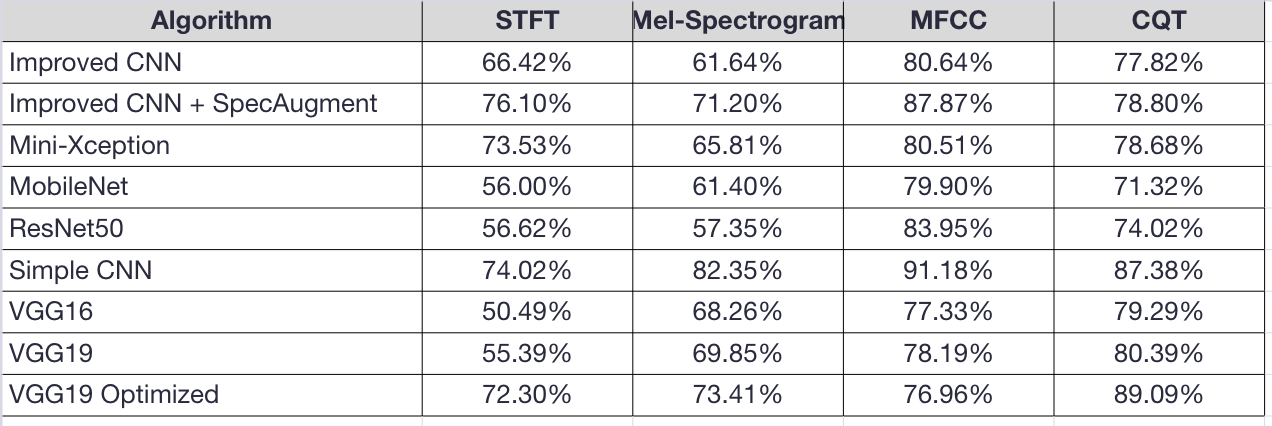

Recall

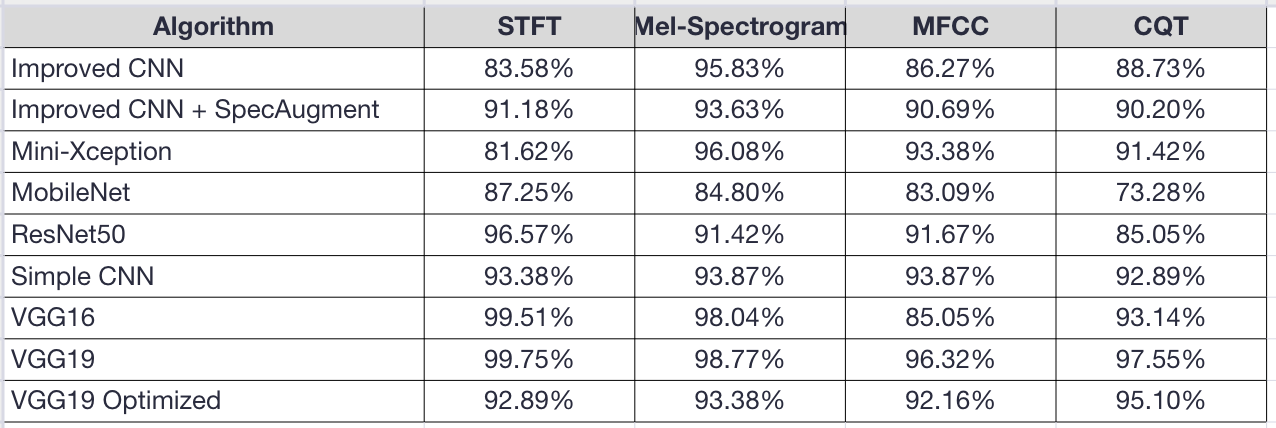

EER

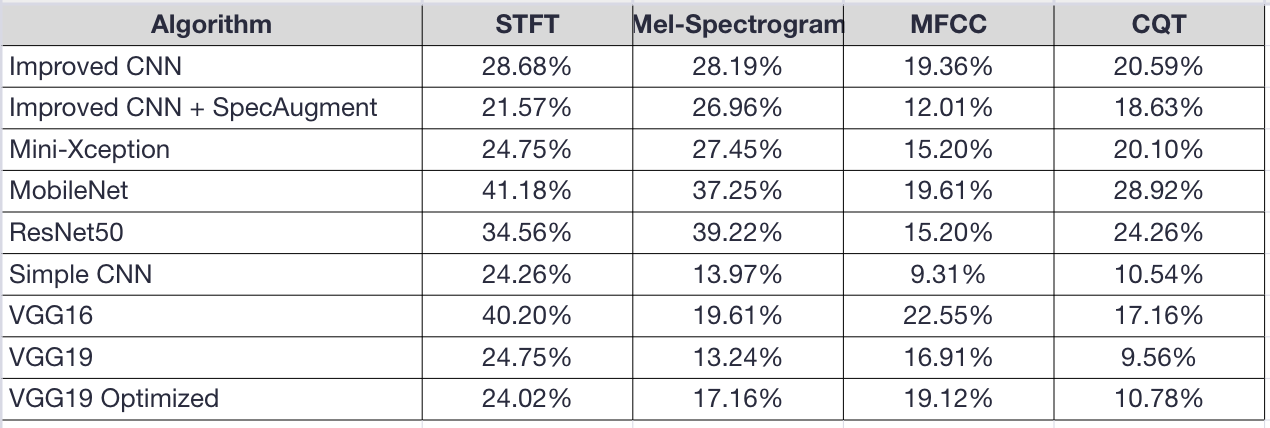

#Load best models

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import tensorflow as tf

simple_cnn_mfcc = tf.keras.models.load_model('/content/drive/MyDrive/simple_cnn_mfcc.keras')

In [ ]:
import tensorflow as tf

vgg19_opt_cqt = tf.keras.models.load_model('/content/drive/MyDrive/vgg19_opt_cqt.keras')

#Load the new data set

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import os, shutil

drive_path = "/content/drive/MyDrive/Da_Audio"
local_path = "/content/da_audio"

if not os.path.exists(local_path):
    shutil.copytree(drive_path, local_path)

base_path = local_path
train_path = os.path.join(base_path, "train")
val_path = os.path.join(base_path, "validation")
test_path = os.path.join(base_path, "test")

for split, split_name in [("train", "train"), ("validation", "val"), ("test", "test")]:
    for label in ["real", "fake"]:
        path = os.path.join(base_path, split, f"{label}_{split_name}_audio")
        if os.path.exists(path):
            count = len([f for f in os.listdir(path) if f.endswith('.wav')])
            print(f"{split}/{label}: {count} files")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
train/real: 5405 files
train/fake: 5405 files
validation/real: 1088 files
validation/fake: 1088 files
test/real: 1100 files
test/fake: 1100 files


In [ ]:
real_path = os.path.join(test_path, "real_test_audio")
fake_path = os.path.join(test_path, "fake_test_audio")

#CQT

###Imports and Parameters

In [ ]:
import os, math, shutil
import numpy as np
import pandas as pd
import tensorflow as tf
import librosa
import librosa.display
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, classification_report,
    f1_score, roc_auc_score, roc_curve,
    recall_score, precision_score
)
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import Callback, EarlyStopping, ModelCheckpoint

SR              = 16000
DURATION        = 2.0
TARGET_LEN      = int(SR * DURATION)
HOP_LENGTH      = 256
FMIN            = 32.7
N_BINS          = 168
BINS_PER_OCTAVE = 24

CQT funktion og load data

In [ ]:
def create_cqt(filepath):
    audio, _ = librosa.load(filepath, sr=SR, mono=True)
    if len(audio) < TARGET_LEN:
        audio = np.pad(audio, (0, TARGET_LEN - len(audio)))
    else:
        audio = audio[:TARGET_LEN]
    C = librosa.cqt(
        audio, sr=SR,
        hop_length=HOP_LENGTH,
        fmin=FMIN,
        n_bins=N_BINS,
        bins_per_octave=BINS_PER_OCTAVE
    )
    C_db = librosa.amplitude_to_db(np.abs(C), ref=np.max)
    return C_db.astype(np.float32)

def get_paths(real_path, fake_path):
    real = sorted([
        os.path.join(real_path, f)
        for f in os.listdir(real_path)
        if f.endswith(".wav")
    ])
    fake = sorted([
        os.path.join(fake_path, f)
        for f in os.listdir(fake_path)
        if f.endswith(".wav")
    ])
    return real, fake

def load_new_test(real_path, fake_path):
    real, fake = get_paths(real_path, fake_path)
    X, y = [], []
    for fp in real:
        X.append(create_cqt(fp))
        y.append(1)
    for fp in fake:
        X.append(create_cqt(fp))
        y.append(0)
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

print("Loading new test data...")
X_new_test, y_new_test = load_new_test(real_path, fake_path)

print("New Test:", X_new_test.shape)
print(f"Data range: {X_new_test.min():.2f} to {X_new_test.max():.2f}")

Loading new test data...


/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=512 is too large for input signal of length=500
  warnings.warn(


New Test: (2200, 168, 126)
Data range: -80.00 to 0.00


RGB Conversions

In [ ]:
def to_rgb_resized(X, size):
    results = []
    for spec in X:
        spec_rgb = np.stack([spec, spec, spec], axis=-1)
        spec_resized = tf.image.resize(spec_rgb, (size, size)).numpy()
        results.append(spec_resized)
    return np.array(results, dtype=np.float32)

print("Converting to RGB...")
X_new_test_vgg = to_rgb_resized(X_new_test, 224)

print("VGG 224:", X_new_test_vgg.shape)
print(f"VGG data range: {X_new_test_vgg.min():.2f} to {X_new_test_vgg.max():.2f}")

Converting to RGB...
VGG 224: (2200, 224, 224, 3)
VGG data range: -80.00 to 0.00


VGG19 Optimized Preprocessing

In [ ]:
from tensorflow.keras.applications.vgg19 import preprocess_input

def to_vgg_optimized_from_rgb(X_rgb):
    X_out = []
    for img in X_rgb:
        img_single = img[:, :, 0]
        img_single = np.flipud(img_single)
        img_stacked = np.stack([img_single, img_single, img_single], axis=-1)
        img_preprocessed = preprocess_input(img_stacked)
        X_out.append(img_preprocessed)
    return np.array(X_out)

X_new_test_vgg_opt = to_vgg_optimized_from_rgb(X_new_test_vgg)
print("VGG Optimized shape:", X_new_test_vgg_opt.shape)

VGG Optimized shape: (2200, 224, 224, 3)


Evaluation Functions

In [ ]:
def equal_error_rate(y_true, y_scores):
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    fnr = 1 - tpr
    idx = np.argmin(np.abs(fpr - fnr))
    return float(fpr[idx])

def bootstrap_ci(y_true, y_scores, n=1000, alpha=0.05):
    accs = []
    n_samples = len(y_true)
    for _ in range(n):
        idx = np.random.randint(0, n_samples, size=n_samples)
        y_b = y_true[idx]
        y_s = y_scores[idx]
        y_p = (y_s >= 0.5).astype(int)
        accs.append(accuracy_score(y_b, y_p))
    lower = np.percentile(accs, 100 * alpha / 2)
    upper = np.percentile(accs, 100 * (1 - alpha / 2))
    return np.mean(accs), lower, upper

def evaluate_model(model, X, y, model_name):
    y_prob  = model.predict(X, verbose=0).ravel()
    y_pred  = (y_prob >= 0.5).astype(int)
    acc     = accuracy_score(y, y_pred)
    recall  = recall_score(y, y_pred)
    prec    = precision_score(y, y_pred, zero_division=0)
    f1      = f1_score(y, y_pred)
    auc     = roc_auc_score(y, y_prob)
    eer     = equal_error_rate(y, y_prob)
    mean_acc, ci_low, ci_high = bootstrap_ci(y, y_prob)

    print(f"\n=== {model_name} ===")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print(f"AUC-ROC:   {auc:.4f}")
    print(f"EER:       {eer:.4f}")
    print(f"Bootstrap: {mean_acc:.4f} [{ci_low:.4f}, {ci_high:.4f}]")

    return {
        "model": model_name, "accuracy": acc, "recall": recall,
        "precision": prec, "f1": f1, "auc": auc, "eer": eer,
        "ci_low": ci_low, "ci_high": ci_high
    }

Load Model

In [ ]:
print("Loading VGG19 Optimized model...")
vgg19_opt_cqt = tf.keras.models.load_model('/content/drive/MyDrive/vgg19_opt_cqt.keras')

Loading VGG19 Optimized model...


Evaluate on New Test Set

In [ ]:
results_vgg = evaluate_model(vgg19_opt_cqt, X_new_test_vgg_opt, y_new_test, "VGG19 Optimized");


=== VGG19 Optimized ===
Accuracy:  0.4968
Recall:    0.6382
Precision: 0.4975
F1-score:  0.5591
AUC-ROC:   0.5465
EER:       0.4664
Bootstrap: 0.4966 [0.4745, 0.5191]


Hovedårsager til det dårlige resultat:

* Sprog-forskel: FoR-datasættet indeholder engelsk tale, mens Da_Audio består af dansk tale. Danske fonemer (æ, ø, å, stød), prosodi og talerytme er fundamentalt forskellige fra engelsk.
* Forskellige TTS-systemer: FoR inkluderer 33 forskellige TTS-systemer (DeepVoice3, Amazon Polly, Google TTS, Microsoft Azure), mens Da_Audio bruger Danske Plapre.
* Rerecording-proces: FoR-rerecorded version indeholder ekstra støj fra rerecording gennem højtaler og mikrofon, hvilket ikke er tilfældet med Da_Audio.
* Audio-kilder: FoR's real speech kommer fra Arctic Dataset, LJSpeech, VoxForge og YouTube, mens Da_Audio bruger danske OpenData optagelser.

Konklusion:
* Domain shift mellem engelsk og dansk tale gør cross-language generalisering umulig for denne model. For at detektere dansk syntetisk tale skal der trænes en ny model specifikt på dansk data.

#MFCC

###Imports and Parameters

In [ ]:
import os, math, shutil
import numpy as np
import pandas as pd
import tensorflow as tf
import librosa
import librosa.display
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, classification_report,
    f1_score, roc_auc_score, roc_curve,
    recall_score, precision_score
)
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import Callback, EarlyStopping, ModelCheckpoint

SR         = 16000
DURATION   = 2.0
TARGET_LEN = int(SR * DURATION)
N_MFCC     = 40
N_FFT      = 1024
HOP_LENGTH = 256
BATCH_SIZE = 16
EPOCHS     = 50
INITIAL_LR = 5e-5
PATIENCE   = 10

MFCC function and load data

In [ ]:
def create_mfcc(filepath):
    audio, _ = librosa.load(filepath, sr=SR, mono=True)
    if len(audio) < TARGET_LEN:
        audio = np.pad(audio, (0, TARGET_LEN - len(audio)))
    else:
        audio = audio[:TARGET_LEN]
    mfcc = librosa.feature.mfcc(
        y=audio, sr=SR, n_mfcc=N_MFCC,
        n_fft=N_FFT, hop_length=HOP_LENGTH
    )
    return mfcc.astype(np.float32)

def get_paths(real_path, fake_path):
    real = sorted([
        os.path.join(real_path, f)
        for f in os.listdir(real_path)
        if f.endswith(".wav")
    ])
    fake = sorted([
        os.path.join(fake_path, f)
        for f in os.listdir(fake_path)
        if f.endswith(".wav")
    ])
    return real, fake

def load_split(real_path, fake_path):
    real, fake = get_paths(real_path, fake_path)
    X, y = [], []
    for fp in real:
        X.append(create_mfcc(fp))
        y.append(1)
    for fp in fake:
        X.append(create_mfcc(fp))
        y.append(0)
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

print("Loading Data...")
X_new_train, y_new_train = load_split(
    os.path.join(train_path, "real_train_audio"),
    os.path.join(train_path, "fake_train_audio")
)
X_new_val, y_new_val = load_split(
    os.path.join(val_path, "real_val_audio"),
    os.path.join(val_path, "fake_val_audio")
)
X_new_test, y_new_test = load_split(
    os.path.join(test_path, "real_test_audio"),
    os.path.join(test_path, "fake_test_audio")
)

print("Train:", X_new_train.shape)
print("Val:  ", X_new_val.shape)
print("Test: ", X_new_test.shape)

Loading Data...
Train: (10810, 40, 126)
Val:   (2176, 40, 126)
Test:  (2200, 40, 126)


Z-score normalization

In [ ]:
print("Z-score normalizing for custom CNNs...")

mean = X_new_train.mean(axis=(0, 1, 2), keepdims=True)
std  = X_new_train.std(axis=(0, 1, 2), keepdims=True) + 1e-8

X_new_train_norm = (X_new_train - mean) / std
X_new_val_norm   = (X_new_val   - mean) / std
X_new_test_norm  = (X_new_test  - mean) / std

X_new_train_norm = X_new_train_norm[..., np.newaxis]
X_new_val_norm   = X_new_val_norm[..., np.newaxis]
X_new_test_norm  = X_new_test_norm[..., np.newaxis]

print("Normalized train shape:", X_new_train_norm.shape)
print("Normalized val shape:  ", X_new_val_norm.shape)
print("Normalized test shape: ", X_new_test_norm.shape)
print(f"\nZ-scored data - Mean: {X_new_train_norm.mean():.6f}, Std: {X_new_train_norm.std():.6f}")
print(f"Z-scored range: {X_new_train_norm.min():.2f} to {X_new_train_norm.max():.2f}")

Z-score normalizing for custom CNNs...
Normalized train shape: (10810, 40, 126, 1)
Normalized val shape:   (2176, 40, 126, 1)
Normalized test shape:  (2200, 40, 126, 1)

Z-scored data - Mean: -0.000000, Std: 1.000000
Z-scored range: -15.18 to 4.00


Evaluation Functions

In [ ]:
def equal_error_rate(y_true, y_scores):
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    fnr = 1 - tpr
    idx = np.argmin(np.abs(fpr - fnr))
    return float(fpr[idx])

def bootstrap_ci(y_true, y_scores, n=1000, alpha=0.05):
    accs = []
    n_samples = len(y_true)
    for _ in range(n):
        idx = np.random.randint(0, n_samples, size=n_samples)
        y_b = y_true[idx]
        y_s = y_scores[idx]
        y_p = (y_s >= 0.5).astype(int)
        accs.append(accuracy_score(y_b, y_p))
    lower = np.percentile(accs, 100 * alpha / 2)
    upper = np.percentile(accs, 100 * (1 - alpha / 2))
    return np.mean(accs), lower, upper

def evaluate_model(model, X, y, model_name):
    y_prob  = model.predict(X, verbose=0).ravel()
    y_pred  = (y_prob >= 0.5).astype(int)
    acc     = accuracy_score(y, y_pred)
    recall  = recall_score(y, y_pred)
    prec    = precision_score(y, y_pred, zero_division=0)
    f1      = f1_score(y, y_pred)
    auc     = roc_auc_score(y, y_prob)
    eer     = equal_error_rate(y, y_prob)
    mean_acc, ci_low, ci_high = bootstrap_ci(y, y_prob)

    print(f"\n=== {model_name} ===")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print(f"AUC-ROC:   {auc:.4f}")
    print(f"EER:       {eer:.4f}")
    print(f"Bootstrap: {mean_acc:.4f} [{ci_low:.4f}, {ci_high:.4f}]")



Load Model

In [ ]:
print("Loading Simple CNN MFCC model...")
simple_cnn_mfcc = tf.keras.models.load_model('/content/drive/MyDrive/simple_cnn_mfcc.keras')

Loading Simple CNN MFCC model...


Evaluate on New Test Set

In [ ]:
evaluate_model(simple_cnn_mfcc, X_new_test_norm, y_new_test, "Simple CNN MFCC")


=== Simple CNN MFCC ===
Accuracy:  0.6695
Recall:    0.5145
Precision: 0.7457
F1-score:  0.6089
AUC-ROC:   0.6912
EER:       0.3555
Bootstrap: 0.6697 [0.6500, 0.6886]


Der er et markant performance-fald på tværs af alle metrics, hvilket er et klart tegn på domæneskift.

Modellen har lært at genkende deepfake-artefakter specifikt fra Fake or Real datasættet, men generaliserer dårligt til dansk tale fra et nyt domæne. Det kan skyldes flere ting:

*   forskelligt sprog
*   forskellig TTS-teknologi brugt til at generere de falske klip
*   forskellig optagelseskvalitet
*   eller at klippene er længere og kun de første 2 sekunder bruges.

Resultatet viser at deepfake-detektion er et svært og domæneafhængigt problem, og motiverer behovet for at træne på domænespecifik data som jeres næste eksperiment netop undersøger.